#loading libraries 

In [4]:
!pip install nltk

In [5]:
import nltk

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

In [7]:
# Download the 'punkt' tokenizer model from nltk
nltk.download("punkt")
# Download the 'stopwords' corpus from nltk
nltk.download("stopwords")

[nltk_data] Downloading package punkt to C:\Users\Yelisetty
[nltk_data]     rahul\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to C:\Users\Yelisetty
[nltk_data]     rahul\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [12]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to C:\Users\Yelisetty
[nltk_data]     rahul\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

Tokenization

In [9]:
# Sample documents about sailing in Croatia
documents = ['Sailing in Croatia often includes visiting UNESCO World Heritage sites.',
 'The Makarska Riviera is known for its stunning coastline and sailing opportunities.',
 'Sailing in Croatia offers stunning views of the Adriatic Sea.',
 "The city of Sibenik is home to the impressive St. James's Cathedral, a UNESCO World Heritage site.",
 'The island of Brač is known for its beautiful beaches and great sailing conditions.',
 'Sailing to the island of Rab, known for its medieval old town, is a great experience.',
 'The Pakleni Islands near Hvar are a popular spot for sailing yachts.',
 'The island of Cres is one of the largest in Croatia and a great destination for sailing.',
 'The island of Cres is one of the largest in Croatia and has a diverse wildlife.',
 'The city of Zagreb is the capital of Croatia and offers a mix of modern and historic attractions.',
 'Sailors can experience the traditional Dalmatian way of life in many coastal villages.',
 'The city of Knin is known for its historic fortress and beautiful scenery.',
 'The island of Krk is the largest island in the Adriatic Sea.',
 'Croatia has a rich history dating back to the Roman Empire.',
 'The island of Hvar is a popular destination for celebrities and high-end travelers.',
 'The city of Varazdin is known for its baroque buildings and vibrant cultural scene.',
 'Sailors can enjoy fresh seafood at many coastal restaurants in Croatia.',
 'The coastal town of Senj is known for its carnival and Nehaj Fortress.',
 'The Dalmatian Coast is a famous region for sailing in Croatia.',
 "The Diocletian's Palace in Split is one of the most famous Roman ruins in Croatia.",
 'The island of Dugi Otok is known for its dramatic cliffs and beautiful sailing waters.',
 'The island of Rab is famous for its medieval old town and stunning beaches.',
 'The island of Mljet is home to a national park and is ideal for nature lovers.',
 'Sailors in Croatia can visit ancient Roman ruins in Split.',
 'The city of Kotor, just across the border in Montenegro, is a popular extension for Croatian sailing trips.',
 'The island of Korcula is believed to be the birthplace of Marco Polo.',
 'The town of Motovun in Istria is famous for its film festival.',
 'The city of Nin is known for its ancient salt pans and historic church.',
 'The city of Vukovar is known for its role in the Croatian War of Independence.',
 'Sailing to the island of Lošinj, known for its health tourism, is a relaxing experience.',
 'The island of Hvar is known for its vibrant nightlife and sailing opportunities.',
 'The island of Korčula is believed to be the birthplace of Marco Polo and is a popular sailing destination.',
 'Sailing in Croatia often involves stopping at picturesque fishing villages.',
 'The city of Opatija is known for its grand villas and seaside promenade.',
 'The city of Porec is known for the Euphrasian Basilica, a UNESCO World Heritage site.',
 'The island of Brac is home to the famous Zlatni Rat beach, known for its changing shape.',
 'Sailing around the island of Mljet offers a peaceful and scenic experience.',
 'The Blue Cave on Biševo Island is a must-see for sailors.',
 'The island of Pag is famous for its cheese and nightlife, and is a fun stop for sailors.',
 "The island of Lastovo is one of Croatia's most remote and tranquil destinations.",
 'Sailors can enjoy snorkeling in the clear waters of the Adriatic Sea.',
 'The city of Rovinj is a charming starting point for a sailing trip in Croatia.',
 "Croatia's national parks, like Krka and Plitvice, are ideal for hiking and nature lovers.",
 'The city of Zadar is famous for its sunsets, which sailors can enjoy from the sea.',
 'Croatia has over a thousand islands, each with its unique charm.',
 "Croatia's Adriatic coast is dotted with charming fishing villages.",
 'Sailing to the island of Šolta offers a quiet escape from the more touristy areas.',
 'Sailors in Croatia can explore over 1,200 islands.',
 'Sailing in Croatia provides opportunities to visit ancient fortresses and castles along the coast.',
 'Croatia is famous for its beautiful coastline and crystal-clear waters.',
 'The island of Krk is accessible by bridge and is a popular starting point for sailing trips.',
 'Sailing in Croatia is best enjoyed during the summer months.',
 'The island of Pag is famous for its cheese, which is considered a delicacy.',
 'The medieval town of Rovinj is one of the most picturesque places in Croatia.',
 'The island of Losinj is famous for its health tourism and clean air.',
 'The city of Dubrovnik, with its famous city walls, is a top destination for sailors.',
 'Croatia has beautiful islands perfect for sailing.',
 'Sailing in Croatia allows you to explore hidden coves and bays.',
 'The city of Rijeka is an important cultural and economic center in Croatia.',
 'The island of Mljet has a national park that is perfect for exploring by sailboat.',
 'The Istrian Peninsula is famous for its truffles and gourmet food.',
 'The town of Cavtat is a quieter alternative to nearby Dubrovnik.',
 'The Peljesac Peninsula is known for its vineyards and wine production.',
 'The Dubrovnik Summer Festival is a major cultural event featuring theater, music, and dance performances.',
 'The city of Zadar is famous for its unique Sea Organ, an architectural sound art object.',
 'The beaches in Croatia are among the best in Europe, with many receiving Blue Flag status.',
 'Sailing around the island of Murter gives access to the Kornati Islands National Park.',
 'The city of Trogir, with its historic architecture, is a great place to dock.',
 'Sailing from Split to Dubrovnik offers breathtaking coastal scenery.',
 'The Plitvice Lakes National Park is a UNESCO World Heritage site known for its stunning waterfalls and lakes.',
 'The city of Hvar is one of the sunniest places in Europe and a popular sailing hub.',
 "The city of Dubrovnik is often called the 'Pearl of the Adriatic'.",
 'The city of Osijek is located in the eastern part of Croatia and is known for its Baroque style.',
 'The city of Pula, with its Roman amphitheater, is a unique sailing destination.',
 'The town of Trogir is a UNESCO World Heritage site known for its medieval architecture.',
 'Sailors in Croatia can enjoy local wines at many coastal vineyards.',
 'Croatia has a Mediterranean climate, making it a great destination year-round.',
 'Croatia has a diverse cultural heritage, with influences from Italy, Hungary, and Austria.',
 'The city of Rijeka is an important cultural and historical sailing destination.',
 'The best sailing routes in Croatia include Dubrovnik and Split.',
 'The Brijuni Islands are a national park and a former presidential retreat.',
 'Sailing to the Elaphiti Islands offers a mix of natural beauty and cultural sites.',
 'Croatia is known for its delicious seafood cuisine.',
 'The ancient city of Pula is known for its well-preserved Roman amphitheater.',
 'The city of Opatija is a historical seaside resort that welcomes sailors.',
 'The waters around Croatia are known for being calm and clear, ideal for sailing.',
 'The Kornati Islands National Park is a popular sailing destination in Croatia.',
 "Sailing around the Brijuni Islands offers a glimpse of Croatia's natural beauty and wildlife.",
 'The island of Vis was a military base and was closed to tourism until the 1990s.',
 'The city of Split is a major port and gateway to the Dalmatian islands.',
 'Sailing to the island of Vis provides access to the famous Blue Cave.',
 "The city of Buzet in Istria is known as the 'City of Truffles'.",
 'The city of Karlovac is known for its parks and the rivers that flow through it.',
 'Sailing to the island of Vis allows you to experience a more remote part of Croatia.',
 'The city of Šibenik is a UNESCO World Heritage site and a great stop for sailors.',
 "The town of Samobor is famous for its traditional cream cake called 'kremsnita'.",
 'Sailing around the island of Lastovo provides a more secluded experience.',
 "Croatia's wine regions produce some excellent wines, especially in Istria and Dalmatia.",
 'Many sailors start their Croatian adventure from the city of Zadar.',
 'The coastal town of Makarska is known for its beautiful beaches and lively nightlife.']

In [10]:
text="The coastal town of Makarska is known for its beautiful beaches and lively nightlife."

In [13]:
sentences=nltk.sent_tokenize(text)
print(f"The tokenized sentences are : {sentences}")

The tokenized sentences are : ['The coastal town of Makarska is known for its beautiful beaches and lively nightlife.']


data Processing

In [15]:
#Process the text : tokenization ,only alphanumeric ,lowering case
processed_text=text.lower()
processed_text=nltk.word_tokenize(processed_text)
processed_text=[word for word in processed_text if word.isalnum()]
processed_text = [word for word in processed_text if word not in nltk.corpus.stopwords.words("english")]
print(f"the processed text is : {processed_text}")

the processed text is : ['coastal', 'town', 'makarska', 'known', 'beautiful', 'beaches', 'lively', 'nightlife']


In [16]:
# Process the text: tokenization, only alphanumeric, lower case, no stopwords
def process_text(text):
    # Convert text to lowercase
    processed_text = text.lower()

    # Tokenize the text into words
    processed_text = nltk.word_tokenize(processed_text)

    # Remove non-alphanumeric tokens
    processed_text = [word for word in processed_text if word.isalnum()]

    # Remove stopwords from the tokenized text
    processed_text = [word for word in processed_text if word not in nltk.corpus.stopwords.words("english")]

    return processed_text

In [20]:
Processed_docs=[' '.join(process_text(doc)) for doc in documents]
Processed_docs

['sailing croatia often includes visiting unesco world heritage sites',
 'makarska riviera known stunning coastline sailing opportunities',
 'sailing croatia offers stunning views adriatic sea',
 'city sibenik home impressive james cathedral unesco world heritage site',
 'island brač known beautiful beaches great sailing conditions',
 'sailing island rab known medieval old town great experience',
 'pakleni islands near hvar popular spot sailing yachts',
 'island cres one largest croatia great destination sailing',
 'island cres one largest croatia diverse wildlife',
 'city zagreb capital croatia offers mix modern historic attractions',
 'sailors experience traditional dalmatian way life many coastal villages',
 'city knin known historic fortress beautiful scenery',
 'island krk largest island adriatic sea',
 'croatia rich history dating back roman empire',
 'island hvar popular destination celebrities travelers',
 'city varazdin known baroque buildings vibrant cultural scene',
 'sailor

Types of retrival systems 

1)BOOLEAN RETRIVAL MODEL
2)VECTOR SPACE MODEL
3) PROBABILISTIC RETRIVAL MODEL

1) boolean model -> ideal for non negotiable and precise requirments
2) vector model -> best for large datasets and partial match queries
3) probabilistic model -> best with historical data for statistical reasoning

Vector model 
1) terms and dimensions
2) vectors
3) similarity


  TF-IDF(Frequency inverse)--> assigns higher values to more important terms

TF-IDF

In [24]:
# Create an instance of TfidfVectorizer
vectorizer = TfidfVectorizer()
# Fit the vectorizer to the preprocessed documents and transform them into a TF-IDF matrix
tfidf_matrix = vectorizer.fit_transform(Processed_docs)
tfidf_matrix.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [25]:
query="sailing island vis provides access famous blue cave"

In [28]:
#try the sample query i9n our documents
query_vec=vectorizer.transform([query])
#query_vec.T.toarray()
results=np.dot(tfidf_matrix,query_vec.T).toarray()
print(f"The results are : {results}")

The results are : [[0.03369702]
 [0.03743522]
 [0.04112898]
 [0.        ]
 [0.0842266 ]
 [0.08294227]
 [0.03301304]
 [0.09151193]
 [0.04742555]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.10208078]
 [0.        ]
 [0.04937865]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.13230012]
 [0.06875115]
 [0.07306097]
 [0.11686887]
 [0.04268022]
 [0.        ]
 [0.02900662]
 [0.04540153]
 [0.07432865]
 [0.        ]
 [0.        ]
 [0.08095354]
 [0.09305055]
 [0.073623  ]
 [0.03384164]
 [0.        ]
 [0.        ]
 [0.09207559]
 [0.08061175]
 [0.46902784]
 [0.1110063 ]
 [0.04521675]
 [0.        ]
 [0.03577181]
 [0.        ]
 [0.0784675 ]
 [0.        ]
 [0.        ]
 [0.07268237]
 [0.        ]
 [0.1592934 ]
 [0.09708682]
 [0.07051405]
 [0.04009178]
 [0.1228012 ]
 [0.        ]
 [0.11154308]
 [0.07243799]
 [0.05396985]
 [0.03541082]
 [0.        ]
 [0.04405591]
 [0.06934008]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.05623599]
 [0.12348432]
 [0.22899342]
 [0.        ]
 [0.03851646]
 [0.        ]
 [

In [29]:
# Function to search the documents based on a query
def search(query, vectorizer, tfidf_matrix):
  # Transform the query into a TF-IDF vector using the provided vectorizer
  query_vec = vectorizer.transform([query])

  # Compute the similarity between the query vector and each document vector
  # This is done by calculating the dot product of the TF-IDF matrix and the query vector
  results = np.dot(tfidf_matrix, query_vec.T).toarray()

  # Return the array of similarity scores
  return results

In [31]:
query="which is largest in Croatia"

In [32]:
# Sort and Display the function
results = search(query, vectorizer, tfidf_matrix)

# Sort the results in descending order based on the similarity scores
sorted_results = sorted(enumerate(results), key = lambda x: x[1][0], reverse = True)

# Iterate over the sorted results to display the outcome
for idx, score in sorted_results:
  print(f"Score {score[0]:.2f}  => Document: {documents[idx]}") # Using idx ( integer) to access the documents

Score 0.49  => Document: The island of Cres is one of the largest in Croatia and a great destination for sailing.
Score 0.46  => Document: The island of Cres is one of the largest in Croatia and has a diverse wildlife.
Score 0.41  => Document: The island of Krk is the largest island in the Adriatic Sea.
Score 0.13  => Document: Sailors in Croatia can explore over 1,200 islands.
Score 0.12  => Document: Croatia has beautiful islands perfect for sailing.
Score 0.11  => Document: Croatia is famous for its beautiful coastline and crystal-clear waters.
Score 0.10  => Document: The Dalmatian Coast is a famous region for sailing in Croatia.
Score 0.10  => Document: Croatia is known for its delicious seafood cuisine.
Score 0.10  => Document: Croatia has over a thousand islands, each with its unique charm.
Score 0.09  => Document: The Kornati Islands National Park is a popular sailing destination in Croatia.
Score 0.09  => Document: Sailing in Croatia offers stunning views of the Adriatic Sea.


Boolean model

1) Tokenization
2) Normalization
3) Inverted Index Creation
4) Query Processing

It is simple and precision

In [33]:
# Process the text: tokenization, remove non-alphanumeric characters, convert to lower case, and remove stopwords (excluding 'and', 'or', 'not')
def process_text_boolean(text):
    # Convert text to lowercase
    processed_text = text.lower()

    # Tokenize the text into words
    processed_text = nltk.word_tokenize(processed_text)

    # Remove non-alphanumeric tokens
    processed_text = [word for word in processed_text if word.isalnum()]

    # Define stopwords excluding 'and', 'or', 'not'
    stopwords = set(nltk.corpus.stopwords.words("english")) - {'and', 'or', 'not'}

    # Remove stopwords from the tokenized text
    processed_text = [word for word in processed_text if word not in stopwords]

    return processed_text

In [34]:
# define a function for the boolean search
def boolean_search(query, documents):
  query_tokens = process_text_boolean(query)

  results = []

  for doc_id, doc in enumerate(documents):
    doc_tokens = set(process_text_boolean(doc))
    include_doc = False

    for i, token in enumerate(query_tokens):
      # Handling the "and" operator
      if token == "and" and i + 1 < len(query_tokens):
        # If the AND operator is found, check if the next token is in the document
        include_doc = include_doc and (query_tokens[i + 1] in doc_tokens)

      elif token == "or" and i + 1 < len(query_tokens):
        # If the OR operator is found, check if the next token is in the document
        include_doc = include_doc or (query_tokens[i + 1] in doc_tokens)

      elif token == "not" and i + 1 < len(query_tokens):
        # If the NOT operator is found, exclude the document if the next token is present
        if query_tokens[i + 1] in doc_tokens:
          include_doc = False
          break # Why is it not exiting the loop?

      else:
        # For normal tokens check if the document should be included
        include_doc = token in doc_tokens or include_doc

    if include_doc:
      results.append((doc_id, doc))

  return results

In [35]:
# Define a search query
query = "Sailing in Split or Hvar"

# Perform the boolean search
boolean_results = boolean_search(query, documents)

print(boolean_results)
# print the results
for doc_id, doc in boolean_results:
  print("Document ID: {}, Document: {}".format(doc_id, doc))

[(0, 'Sailing in Croatia often includes visiting UNESCO World Heritage sites.'), (1, 'The Makarska Riviera is known for its stunning coastline and sailing opportunities.'), (2, 'Sailing in Croatia offers stunning views of the Adriatic Sea.'), (4, 'The island of Brač is known for its beautiful beaches and great sailing conditions.'), (5, 'Sailing to the island of Rab, known for its medieval old town, is a great experience.'), (6, 'The Pakleni Islands near Hvar are a popular spot for sailing yachts.'), (7, 'The island of Cres is one of the largest in Croatia and a great destination for sailing.'), (14, 'The island of Hvar is a popular destination for celebrities and high-end travelers.'), (18, 'The Dalmatian Coast is a famous region for sailing in Croatia.'), (19, "The Diocletian's Palace in Split is one of the most famous Roman ruins in Croatia."), (20, 'The island of Dugi Otok is known for its dramatic cliffs and beautiful sailing waters.'), (23, 'Sailors in Croatia can visit ancient R

Propabilistic rag

1) Relevance Propability
2) query terms
3) Document terms
4) binary independence
   

In [36]:
# Install the rank_bm25 library
# BM25 is a probabilistic-based ranking function used in information retrieval to rank documents
!pip install rank_bm25

In [37]:
# Import the BM25Okapi class
from rank_bm25 import BM25Okapi

In [38]:
Processed_docs

['sailing croatia often includes visiting unesco world heritage sites',
 'makarska riviera known stunning coastline sailing opportunities',
 'sailing croatia offers stunning views adriatic sea',
 'city sibenik home impressive james cathedral unesco world heritage site',
 'island brač known beautiful beaches great sailing conditions',
 'sailing island rab known medieval old town great experience',
 'pakleni islands near hvar popular spot sailing yachts',
 'island cres one largest croatia great destination sailing',
 'island cres one largest croatia diverse wildlife',
 'city zagreb capital croatia offers mix modern historic attractions',
 'sailors experience traditional dalmatian way life many coastal villages',
 'city knin known historic fortress beautiful scenery',
 'island krk largest island adriatic sea',
 'croatia rich history dating back roman empire',
 'island hvar popular destination celebrities travelers',
 'city varazdin known baroque buildings vibrant cultural scene',
 'sailor

In [39]:
# Tokenize each cleaned document
tokenined_docs = [process_text(doc) for doc in documents]
tokenined_docs

[['sailing',
  'croatia',
  'often',
  'includes',
  'visiting',
  'unesco',
  'world',
  'heritage',
  'sites'],
 ['makarska',
  'riviera',
  'known',
  'stunning',
  'coastline',
  'sailing',
  'opportunities'],
 ['sailing', 'croatia', 'offers', 'stunning', 'views', 'adriatic', 'sea'],
 ['city',
  'sibenik',
  'home',
  'impressive',
  'james',
  'cathedral',
  'unesco',
  'world',
  'heritage',
  'site'],
 ['island',
  'brač',
  'known',
  'beautiful',
  'beaches',
  'great',
  'sailing',
  'conditions'],
 ['sailing',
  'island',
  'rab',
  'known',
  'medieval',
  'old',
  'town',
  'great',
  'experience'],
 ['pakleni',
  'islands',
  'near',
  'hvar',
  'popular',
  'spot',
  'sailing',
  'yachts'],
 ['island',
  'cres',
  'one',
  'largest',
  'croatia',
  'great',
  'destination',
  'sailing'],
 ['island', 'cres', 'one', 'largest', 'croatia', 'diverse', 'wildlife'],
 ['city',
  'zagreb',
  'capital',
  'croatia',
  'offers',
  'mix',
  'modern',
  'historic',
  'attractions'],


In [40]:
model=BM25Okapi(tokenined_docs)

In [43]:
# Function to perform a BM25 search on the documents
def bm25_search(query,model):
    query_tokens = process_text(query)
    docs_score=model.get_scores(query_tokens)
    return docs_score

In [44]:
query="top 10 things to do in Croatia"
bm_results=bm25_search(query,model)

In [49]:
bm_results


array([0.52474608, 0.        , 0.58932138, 0.        , 0.        ,
       0.        , 0.        , 0.55516222, 0.58932138, 0.52474608,
       0.        , 0.        , 0.        , 0.58932138, 0.        ,
       0.        , 0.55516222, 0.        , 0.62795978, 0.55516222,
       0.        , 0.        , 0.        , 0.58932138, 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.55516222, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.58932138,
       0.        , 0.55516222, 0.49748969, 0.        , 0.67202026,
       0.58932138, 0.        , 0.72273026, 0.49748969, 0.67202026,
       0.        , 0.62795978, 0.        , 0.58932138, 0.        ,
       4.09014265, 0.67202026, 0.58932138, 0.58932138, 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.49748969, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.52474608, 0.        , 0.     

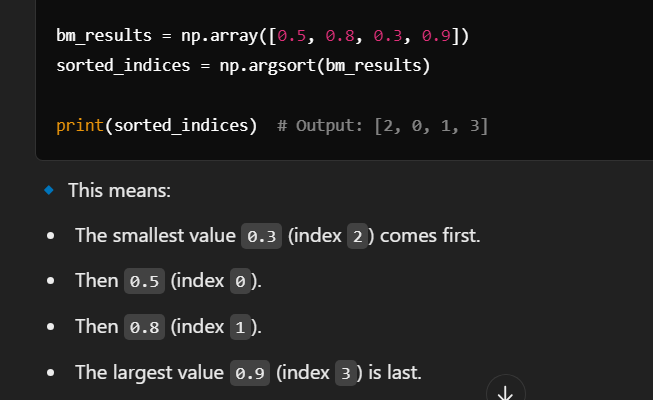

In [47]:
# Sort the results in descending order of relevance scores
sorted_bm25_results = np.argsort(bm_results)[::-1]

# Display the sorted BM25 search results
for idx in sorted_bm25_results:
  print("Score: {:.3f} => Document: {}".format(bm_results[idx], documents[idx]))

Score: 4.090 => Document: The city of Dubrovnik, with its famous city walls, is a top destination for sailors.
Score: 0.723 => Document: Sailors in Croatia can explore over 1,200 islands.
Score: 0.672 => Document: Croatia is famous for its beautiful coastline and crystal-clear waters.
Score: 0.672 => Document: Croatia has beautiful islands perfect for sailing.
Score: 0.672 => Document: Croatia has over a thousand islands, each with its unique charm.
Score: 0.672 => Document: Croatia is known for its delicious seafood cuisine.
Score: 0.628 => Document: Sailing in Croatia is best enjoyed during the summer months.
Score: 0.628 => Document: Croatia has a Mediterranean climate, making it a great destination year-round.
Score: 0.628 => Document: The Dalmatian Coast is a famous region for sailing in Croatia.
Score: 0.589 => Document: The city of Rijeka is an important cultural and economic center in Croatia.
Score: 0.589 => Document: The medieval town of Rovinj is one of the most picturesque 